##Nama : MUHAMAD ROFI ALJUFRI
##Nim : 23.11.5912

###1. SETUP & IMPORT

In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

###2. LOAD DATASET

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Semester 5/BIG DATA MINING/Dataset UAS Big Mining/motogp_cleaned_dataset.csv')
df.head()

,year,category,sequence,shortname,circuit_name,rider,rider_name,team_name,bike_name,position,points,number,country,speed,time
0,1949,500cc,1,TT,Isle of Man,6,"Daniell, Harold",?,Norton,1,10.0,NaN,GB,NaN,3:02'18.600
1,1949,500cc,1,TT,Isle of Man,7,"Lockett, John",?,Norton,2,8.0,NaN,GB,NaN,0 Lap
2,1949,500cc,1,TT,Isle of Man,8,"Lyons, Ernie",?,Velocette,3,7.0,NaN,IE,NaN,0 Lap
3,1949,500cc,1,TT,Isle of Man,5,"Bell, Artie",?,Norton,4,6.0,NaN,IE,NaN,0 Lap
4,1949,500cc,1,TT,Isle of Man,12,"Jensen, Sid",?,Triumph,5,5.0,NaN,NZ,NaN,0 Lap


###3. EDA (Exploratory Data Analysis)

In [ ]:
df.info()
df.describe()
print("Missing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55950 entries, 0 to 55949
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          55950 non-null  int64  
 1   category      55950 non-null  object 
 2   sequence      55950 non-null  int64  
 3   shortname     55950 non-null  object 
 4   circuit_name  55950 non-null  object 
 5   rider         55950 non-null  int64  
 6   rider_name    55950 non-null  object 
 7   team_name     55950 non-null  object 
 8   bike_name     55950 non-null  object 
 9   position      55950 non-null  int64  
 10  points        55950 non-null  float64
 11  number        24803 non-null  float64
 12  country       55950 non-null  object 
 13  speed         33171 non-null  float64
 14  time          55950 non-null  object 
dtypes: float64(3), int64(4), object(8)
memory usage: 6.4+ MB
Missing values:
 year                0
category            0
sequence            0
shortname      

Visualisasi distribusi posisi

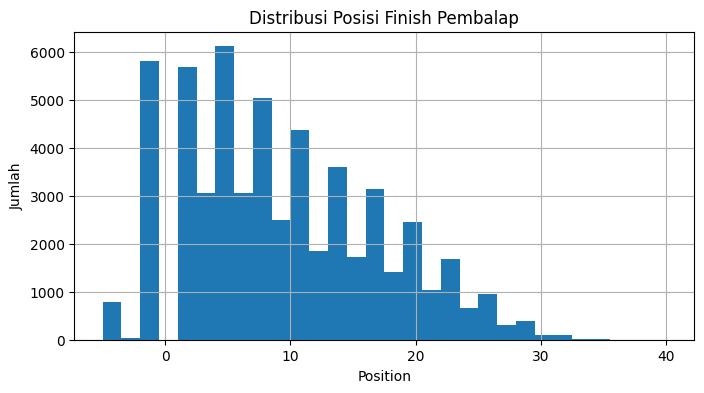

In [ ]:
plt.figure(figsize=(8,4))
df['position'].hist(bins=30)
plt.title("Distribusi Posisi Finish Pembalap")
plt.xlabel("Position")
plt.ylabel("Jumlah")
plt.show()

Korelasi numerik

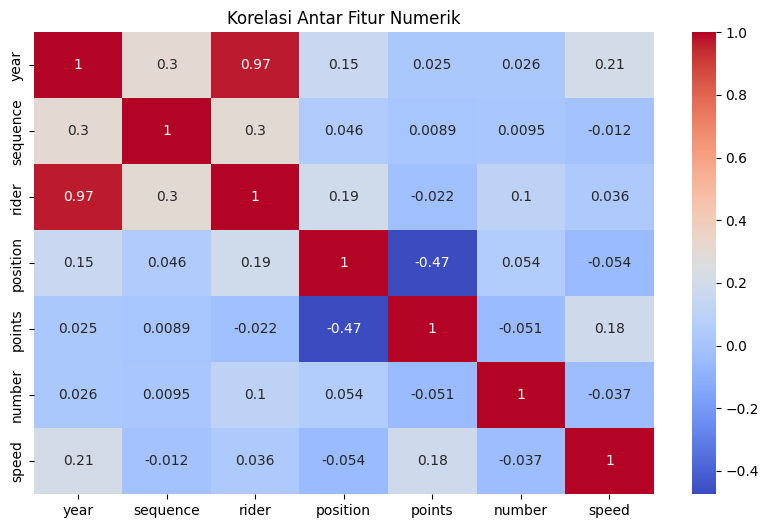

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Korelasi Antar Fitur Numerik")
plt.show()

###4. PREPROCESSING + TARGET PODIUM

In [ ]:
# Buat target klasifikasi biner
df['podium'] = df['position'].apply(lambda x: 1 if x <= 3 else 0)

# Drop kolom tidak relevan
columns_to_drop = ['position','number','speed','time','rider','rider_name','team_name','bike_name','shortname','circuit_name']
df_clean = df.drop(columns=columns_to_drop)

# Tangani missing
df_clean.fillna(df_clean.mean(numeric_only=True), inplace=True)

# Encoding
df_clean = pd.get_dummies(df_clean, columns=['category','country'], drop_first=True)

X = df_clean.drop('podium', axis=1)
y = df_clean['podium']

###5. SPLIT + SCALING

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###6. FEATURE IMPORTANCE (Seleksi Fitur)

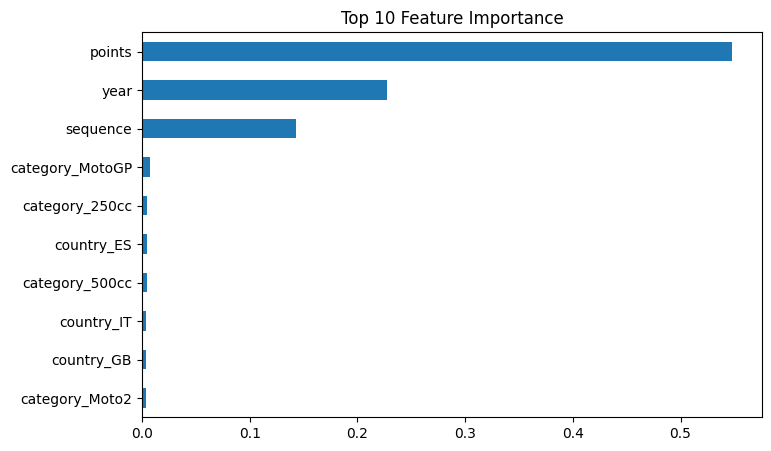

In [ ]:
rf_temp = RandomForestClassifier(n_estimators=200, random_state=42)
rf_temp.fit(X_train, y_train)

feat_imp = pd.Series(rf_temp.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

###7. MODELING

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print("\n====", name, "====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))


==== Random Forest ====
Accuracy: 0.886386654751266
              precision    recall  f1-score   support

           0       0.91      0.94      0.92     12036
           1       0.83      0.75      0.79      4749

    accuracy                           0.89     16785
   macro avg       0.87      0.85      0.86     16785
weighted avg       0.88      0.89      0.88     16785

[[11299   737]
 [ 1170  3579]]

==== Logistic Regression ====
Accuracy: 0.8078045874292523
              precision    recall  f1-score   support

           0       0.80      0.98      0.88     12036
           1       0.89      0.37      0.52      4749

    accuracy                           0.81     16785
   macro avg       0.84      0.67      0.70     16785
weighted avg       0.82      0.81      0.78     16785

[[11813   223]
 [ 3003  1746]]


###8. SIMPAN MODEL

In [ ]:
best_model = RandomForestClassifier(n_estimators=300, random_state=42)
best_model.fit(X_train_scaled, y_train)

joblib.dump(best_model, "model_motogp_podium.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']